In [ ]:
# Install (if needed)
!pip install torchvision

# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

In [ ]:
import os
import zipfile
import shutil

# Define path to the compressed dataset file
zip_path = '/content/drive/MyDrive/data_2006.zip'

# Define extraction directory
data_dir = 'data'

# Remove existing 'data' directory to ensure a clean extraction
if os.path.exists(data_dir):
    shutil.rmtree(data_dir)
os.makedirs(data_dir, exist_ok=True)

print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(path=data_dir)

print("Extraction complete.")

Extracting /content/drive/MyDrive/data_2006.zip...
Extraction complete.


In [ ]:
print('Listing contents of the data directory:')
!ls -F data

print('\nListing contents of first-level subdirectories (if any):')
# This might fail if there are no subdirectories, but will help diagnose
try:
    for item in os.listdir('data'):
        item_path = os.path.join('data', item)
        if os.path.isdir(item_path):
            print(f'Contents of {item_path}:')
            !ls -F "{item_path}"
except Exception as e:
    print(f'Could not list subdirectories: {e}')

Listing contents of the data directory:
dataset/  dataset-test/

Listing contents of first-level subdirectories (if any):
Contents of data/dataset:
negative/  positive/
Contents of data/dataset-test:
classes.txt  images/  labels/  notes.json


In [ ]:
# Inspect the extracted directory structure
print("Contents of data directory:")
!ls -R {data_dir}

Contents of data directory:
data:
dataset  dataset-test

data/dataset:
negative  positive

data/dataset/negative:
'0001 (2).jpg'	'0029 (2).jpg'	 0056.jpg	 0083.jpg	 0132.jpg
 0001.jpg	'0029(2).jpg'	'0057 (2).jpg'	'0084 (2).jpg'	 0133.jpg
'0002 (2).jpg'	 0029.jpg	'0057 (3).jpg'	'0084 (3).jpg'	 0134.jpg
'0002 (3).jpg'	'0030 (2).jpg'	 0057.jpg	 0084.jpg	 0135.jpg
 0002.jpg	'0030 (3).jpg'	'0058 (2).jpg'	'0085 (2).jpg'	 0136.jpg
'0003 (2).jpg'	 0030.jpg	'0058 (3).jpg'	'0085 (3).jpg'	 0137.jpg
'0003 (3).jpg'	'0031 (2).jpg'	 0058.jpg	 0085.jpg	 0138.jpg
 0003.jpg	'0031 (3).jpg'	'0059 (2).jpg'	'0086 (2).jpg'	 0139.jpg
'0004 (2).jpg'	 0031.jpg	'0059 (3).jpg'	 0086.jpg	 0140.jpg
'0004 (3).jpg'	'0032 (2).jpg'	 0059.jpg	'0087 (2).jpg'	 0141.jpg
 0004.jpg	'0032 (3).jpg'	'0060 (2).jpg'	'0087 (3).jpg'	 0142.jpg
'0005 (2).jpg'	 0032.jpg	 0060.jpg	 0087.jpg	 0143.jpg
'0005 (3).jpg'	'0033 (2).jpg'	'0061 (2).jpg'	'0088 (2).jpg'	 0144.jpg
 0005.jpg	 0033.jpg	 0061.jpg	 0088.jpg	 0145.jpg
'0006 (2).jpg'	'0

In [ ]:
import os
from sklearn.model_selection import train_test_split
import shutil
import random

# Define the root directory where data is extracted
# Based on the current directory listing, the zip extracts into 'data/dataset'
root_data_dir = './data/dataset'

# Define the destination directories for the sampled and split data
sampled_data_dir = 'sampled_data'
train_dir = os.path.join(sampled_data_dir, 'train')
val_dir = os.path.join(sampled_data_dir, 'val')
test_dir = os.path.join(sampled_data_dir, 'test')

# Remove sampled_data directory if it exists to ensure a clean slate
shutil.rmtree(sampled_data_dir, ignore_errors=True)

# Create the destination directories
for d in [train_dir, val_dir, test_dir]:
    os.makedirs(os.path.join(d, 'HPNegative'), exist_ok=True)
    os.makedirs(os.path.join(d, 'HPPositive'), exist_ok=True)

# Function to sample and split data for a given class
def sample_and_split(source_class_dir, train_dest, val_dest, test_dest, sample_percent=0.50, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    # Debugging: Print all files found before filtering
    all_raw_files = os.listdir(source_class_dir)
    print(f"DEBUG: All raw files in {source_class_dir}: {all_raw_files}")

    # Make file extension check case-insensitive
    all_files = [os.path.join(source_class_dir, f) for f in all_raw_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"DEBUG: Filtered files in {source_class_dir}: {all_files}")

    # Sample a percentage of the files
    num_to_sample = int(len(all_files) * sample_percent)
    if num_to_sample < 3 and len(all_files) >= 3: # Ensure at least 3 files for splitting if available
        num_to_sample = int(len(all_files) * 0.5) if int(len(all_files) * 0.5) >=3 else 3 # Try 50%, or minimum 3
    elif num_to_sample == 0 and len(all_files) > 0: # If sampling 0, but files exist, sample minimum 1
        num_to_sample = 1
    elif num_to_sample == 0 and len(all_files) == 0:
        print(f"Warning: No files found in {source_class_dir} to sample.")
        return

    sampled_files = random.sample(all_files, num_to_sample)

    print(f"Original files in {source_class_dir}: {len(all_files)}")
    print(f"Sampled files for {source_class_dir}: {len(sampled_files)}")

    # Adjust ratios if sampled_files is too small to avoid empty sets
    if len(sampled_files) < 3:
        print(f"Warning: Not enough sampled files ({len(sampled_files)}) in {source_class_dir} for 3-way split. Skipping validation/test split.")
        if len(sampled_files) > 0:
            # If only 1 or 2 files, put them all in train, or just create a test set if 1 file.
            train_files = sampled_files
            val_files = []
            test_files = []
        else:
            train_files = []
            val_files = []
            test_files = []
    else:
        # Split sampled files into train, val, test
        train_val_files, test_files = train_test_split(sampled_files, test_size=test_ratio, random_state=42)
        train_files, val_files = train_test_split(train_val_files, test_size=val_ratio/(train_ratio + val_ratio), random_state=42)

    # Copy files to respective directories
    for f in train_files:
        shutil.copy(f, train_dest)
    for f in val_files:
        shutil.copy(f, val_dest)
    for f in test_files:
        shutil.copy(f, test_dest)

    print(f"  Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")


# Process Negative (source folder name - 'negative' in the extracted data)
sample_and_split(os.path.join(root_data_dir, 'negative'),
                 os.path.join(train_dir, 'HPNegative'), # Destination folder name
                 os.path.join(val_dir, 'HPNegative'),   # Destination folder name
                 os.path.join(test_dir, 'HPNegative'),
                 sample_percent=1)  # Increased sample percentage

# Process Positive (source folder name - 'positive' in the extracted data)
sample_and_split(os.path.join(root_data_dir, 'positive', 'images'), # Corrected path for positive images
                 os.path.join(train_dir, 'HPPositive'), # Destination folder name
                 os.path.join(val_dir, 'HPPositive'),   # Destination folder name
                 os.path.join(test_dir, 'HPPositive'),
                 sample_percent=1)  # Increased sample percentage

print("Dataset sampling and splitting complete.")

DEBUG: All raw files in ./data/dataset/negative: ['0167.jpg', '0009.jpg', '0096 (2).jpg', '0077 (3).jpg', '0022 (2).jpg', '0084.jpg', '0155.jpg', '0041.jpg', '0149.jpg', '0047 (3).jpg', '0075 (2).jpg', '0113.jpg', '0073 (2).jpg', '0085.jpg', '0032.jpg', '0002 (3).jpg', '0107.jpg', '0008 (2).jpg', '0023 (2).jpg', '0045.jpg', '0066.jpg', '0169.jpg', '0184.jpg', '0016 (2).jpg', '0072.jpg', '0058 (3).jpg', '0082 (2).jpg', '0027(1).jpg', '0022 (3).jpg', '0048.jpg', '0029.jpg', '0062 (2).jpg', '0199.jpg', '0096 (3).jpg', '0037 (2).jpg', '0092 (2).jpg', '0099 (2).jpg', '0058.jpg', '0142.jpg', '0081.jpg', '0010 (3).jpg', '0083.jpg', '0102.jpg', '0077 (2).jpg', '0190.jpg', '0194.jpg', '0011 (2).jpg', '0115.jpg', '0054 (3).jpg', '0053 (2).jpg', '0059 (2).jpg', '0014 (2).jpg', '0025 (2).jpg', '0049.jpg', '0097 (2).jpg', '0095 (3).jpg', '0015 (2).jpg', '0110.jpg', '0128.jpg', '0180.jpg', '0130.jpg', '0052.jpg', '0200.jpg', '0087 (3).jpg', '0111.jpg', '0100.jpg', '0078 (3).jpg', '0103.jpg', '0067.j

In [ ]:
print('Listing contents of data/minor_dataset/pos:')
!ls -F "./data/minor_dataset/pos"

# Also check if the directory exists and is empty
import os
pos_dir = './data/minor_dataset/pos'
if not os.path.exists(pos_dir):
    print(f"Error: Directory {pos_dir} does not exist.")
elif not os.listdir(pos_dir):
    print(f"Warning: Directory {pos_dir} is empty.")
else:
    print(f"Directory {pos_dir} contains files, but they might not be images or have unexpected extensions.")

Listing contents of data/minor_dataset/pos:
ls: cannot access './data/minor_dataset/pos': No such file or directory
Error: Directory ./data/minor_dataset/pos does not exist.


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define image transformations for data augmentation and normalization
# These are common transformations for ImageNet pre-trained models like ResNet
image_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # Randomly crop the image and resize to 224x224
        transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally
        transforms.ToTensor(), # Convert image to PyTorch Tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalize with ImageNet stats
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), # Resize to 256
        transforms.CenterCrop(224), # Crop the center to 224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Create datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=image_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=image_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=image_transforms['test'])

# Define batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Dataset structure and image count:")
print(f"  Classes: {train_dataset.classes}")
print(f"  Class to index mapping: {train_dataset.class_to_idx}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print("DataLoaders created successfully.")

Dataset structure and image count:
  Classes: ['HPNegative', 'HPPositive']
  Class to index mapping: {'HPNegative': 0, 'HPPositive': 1}
Number of training samples: 1613
Number of validation samples: 347
Number of test samples: 347
DataLoaders created successfully.


In [ ]:
# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pre-trained ResNet50 model
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters in the network
for param in resnet50.parameters():
    param.requires_grad = False

# Modify the final classification layer for 2 classes (HPNegative, HPPositive)
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

# Move the model to the specified device
resnet50 = resnet50.to(device)

print("ResNet50 model loaded and modified for 2 classes.")
print(f"Output classes: {train_dataset.classes}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


ResNet50 model loaded and modified for 2 classes.
Output classes: ['HPNegative', 'HPPositive']


In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.fc.parameters(), lr=0.001) # Only optimize the new classification layer

In [ ]:
import time
import copy
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np # Added for efficient tensor conversion

# Function to calculate metrics
def calculate_metrics(y_true, y_pred_proba, y_pred_labels):
    accuracy = accuracy_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels, average='weighted') # Or 'binary' for 2 classes
    # Handle cases where y_true might have only one class or y_pred_proba is flat
    try:
        # Ensure y_true only contains 0 and 1 for binary ROC AUC
        if len(np.unique(y_true)) > 2: # If more than 2 unique labels, it's multi-class
            roc_auc = float('nan') # Cannot compute binary ROC-AUC directly
        else:
            roc_auc = roc_auc_score(y_true, y_pred_proba[:, 1]) # Assuming positive class is index 1
    except ValueError:
        # If only one class is present in y_true, ROC AUC is undefined
        roc_auc = float('nan') # Not a Number
    return accuracy, f1, roc_auc


# Training function
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            all_labels = []
            all_preds_proba = []
            all_preds_labels = []

            # Iterate over data.
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_labels.extend(labels.cpu().numpy())
                # Detach tensors before converting to numpy
                all_preds_proba.extend(torch.softmax(outputs, dim=1).detach().cpu().numpy())
                all_preds_labels.extend(preds.detach().cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Pass a tensor to calculate_metrics as it expects torch.tensor
            # Convert list of numpy arrays to a single numpy array then to torch.tensor for efficiency
            accuracy, f1, roc_auc = calculate_metrics(all_labels, torch.from_numpy(np.array(all_preds_proba)), all_preds_labels)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {f1:.4f} ROC-AUC: {roc_auc:.4f}')

            # deep copy the model if it's the best validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Train the model
resnet50_model, resnet50_history = train_model(resnet50, criterion, optimizer, num_epochs=5) # You can adjust num_epochs

Epoch 0/4
----------
train Loss: 0.3660 Acc: 0.8636 F1: 0.8215 ROC-AUC: 0.7768
val Loss: 0.2482 Acc: 0.9135 F1: 0.9015 ROC-AUC: 0.9382

Epoch 1/4
----------
train Loss: 0.2510 Acc: 0.9020 F1: 0.8912 ROC-AUC: 0.9240
val Loss: 0.1958 Acc: 0.9222 F1: 0.9173 ROC-AUC: 0.9597

Epoch 2/4
----------
train Loss: 0.2022 Acc: 0.9250 F1: 0.9197 ROC-AUC: 0.9520
val Loss: 0.1767 Acc: 0.9452 F1: 0.9446 ROC-AUC: 0.9713

Epoch 3/4
----------
train Loss: 0.2011 Acc: 0.9225 F1: 0.9176 ROC-AUC: 0.9511
val Loss: 0.1484 Acc: 0.9452 F1: 0.9418 ROC-AUC: 0.9785

Epoch 4/4
----------
train Loss: 0.1761 Acc: 0.9237 F1: 0.9203 ROC-AUC: 0.9647
val Loss: 0.1470 Acc: 0.9481 F1: 0.9440 ROC-AUC: 0.9811

Training complete in 8m 23s
Best val Acc: 0.948127


In [ ]:
import torch

# Save the trained ResNet50 model
torch.save(resnet50_model.state_dict(), '/content/drive/MyDrive/resnet50_h_pylori.pth')
print("ResNet50 model saved to Google Drive.")

ResNet50 model saved to Google Drive.


In [ ]:
import torch.nn as nn
from torchvision import models

# Load pre-trained DenseNet121 model
densenet121 = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Freeze all parameters in the network
for param in densenet121.parameters():
    param.requires_grad = False

# Modify the final classification layer for 2 classes
num_ftrs_densenet = densenet121.classifier.in_features
densenet121.classifier = nn.Linear(num_ftrs_densenet, len(train_dataset.classes))

# Move the model to the specified device
densenet121 = densenet121.to(device)

print("DenseNet121 model loaded and modified for 2 classes.")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 131MB/s]


DenseNet121 model loaded and modified for 2 classes.


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion_densenet = nn.CrossEntropyLoss()
optimizer_densenet = optim.Adam(densenet121.classifier.parameters(), lr=0.001) # Only optimize the new classification layer

In [ ]:
# Train the DenseNet121 model
densenet121_model, densenet121_history = train_model(densenet121, criterion_densenet, optimizer_densenet, num_epochs=5) # You can adjust num_epochs

Epoch 0/4
----------
train Loss: 0.3897 Acc: 0.8407 F1: 0.7794 ROC-AUC: 0.7442
val Loss: 0.2941 Acc: 0.8963 F1: 0.8753 ROC-AUC: 0.9186

Epoch 1/4
----------
train Loss: 0.2927 Acc: 0.8779 F1: 0.8519 ROC-AUC: 0.9009
val Loss: 0.2475 Acc: 0.8963 F1: 0.8753 ROC-AUC: 0.9393

Epoch 2/4
----------
train Loss: 0.2474 Acc: 0.9051 F1: 0.8937 ROC-AUC: 0.9291
val Loss: 0.2106 Acc: 0.9222 F1: 0.9118 ROC-AUC: 0.9593

Epoch 3/4
----------
train Loss: 0.2466 Acc: 0.9070 F1: 0.8989 ROC-AUC: 0.9218
val Loss: 0.2307 Acc: 0.9020 F1: 0.8839 ROC-AUC: 0.9604

Epoch 4/4
----------
train Loss: 0.2123 Acc: 0.9188 F1: 0.9120 ROC-AUC: 0.9477
val Loss: 0.1869 Acc: 0.9366 F1: 0.9361 ROC-AUC: 0.9716

Training complete in 7m 31s
Best val Acc: 0.936599


In [ ]:
import torch

# Save the trained DenseNet121 model
torch.save(densenet121_model.state_dict(), '/content/drive/MyDrive/densenet121_h_pylori.pth')
print("DenseNet121 model saved to Google Drive.")

DenseNet121 model saved to Google Drive.


In [ ]:
import torch.nn as nn
from torchvision import models

# Load pre-trained EfficientNetV2_S model
efficientnet_v2_s = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)

# Freeze all parameters in the network
for param in efficientnet_v2_s.parameters():
    param.requires_grad = False

# Modify the final classification layer for 2 classes
num_ftrs_efficientnet = efficientnet_v2_s.classifier[1].in_features
efficientnet_v2_s.classifier[1] = nn.Linear(num_ftrs_efficientnet, len(train_dataset.classes))

# Move the model to the specified device
efficientnet_v2_s = efficientnet_v2_s.to(device)

print("EfficientNetV2_S model loaded and modified for 2 classes.")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 132MB/s]


EfficientNetV2_S model loaded and modified for 2 classes.


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion_efficientnet = nn.CrossEntropyLoss()
optimizer_efficientnet = optim.Adam(efficientnet_v2_s.classifier.parameters(), lr=0.001) # Only optimize the new classification layer

In [ ]:
# Train the EfficientNetV2_S model
efficientnet_v2_s_model, efficientnet_v2_s_history = train_model(efficientnet_v2_s, criterion_efficientnet, optimizer_efficientnet, num_epochs=5) # You can adjust num_epochs

Epoch 0/4
----------
train Loss: 0.4867 Acc: 0.7805 F1: 0.7687 ROC-AUC: 0.6531
val Loss: 0.3936 Acc: 0.8559 F1: 0.8489 ROC-AUC: 0.8229

Epoch 1/4
----------
train Loss: 0.4229 Acc: 0.8140 F1: 0.8125 ROC-AUC: 0.7738
val Loss: 0.3479 Acc: 0.8963 F1: 0.8939 ROC-AUC: 0.8820

Epoch 2/4
----------
train Loss: 0.3639 Acc: 0.8462 F1: 0.8335 ROC-AUC: 0.8164
val Loss: 0.3146 Acc: 0.8905 F1: 0.8905 ROC-AUC: 0.9025

Epoch 3/4
----------
train Loss: 0.3503 Acc: 0.8599 F1: 0.8551 ROC-AUC: 0.8436
val Loss: 0.3235 Acc: 0.8818 F1: 0.8838 ROC-AUC: 0.9085

Epoch 4/4
----------
train Loss: 0.3313 Acc: 0.8555 F1: 0.8538 ROC-AUC: 0.8704
val Loss: 0.2809 Acc: 0.9049 F1: 0.9031 ROC-AUC: 0.9134

Training complete in 6m 56s
Best val Acc: 0.904899


In [ ]:
import torch

# Save the trained EfficientNetV2 model
torch.save(efficientnet_v2_s_model.state_dict(), '/content/drive/MyDrive/efficientnet_v2_h_pylori.pth')
print("EfficientNetV2 model saved to Google Drive.")

EfficientNetV2 model saved to Google Drive.


In [ ]:
import torch.nn as nn
from torchvision import models

# Load pre-trained Vision Transformer (ViT_B_16) model
vit_b_16 = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Freeze all parameters in the network
for param in vit_b_16.parameters():
    param.requires_grad = False

# Modify the final classification head for 2 classes
num_ftrs_vit = vit_b_16.heads.head.in_features
vit_b_16.heads.head = nn.Linear(num_ftrs_vit, len(train_dataset.classes))

# Move the model to the specified device
vit_b_16 = vit_b_16.to(device)

print("Vision Transformer (ViT_B_16) model loaded and modified for 2 classes.")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 75.9MB/s]


Vision Transformer (ViT_B_16) model loaded and modified for 2 classes.


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.Adam(vit_b_16.heads.head.parameters(), lr=0.001) # Only optimize the new classification layer

In [ ]:
# Train the ViT model
vit_b_16_model, vit_b_16_history = train_model(vit_b_16, criterion_vit, optimizer_vit, num_epochs=5)

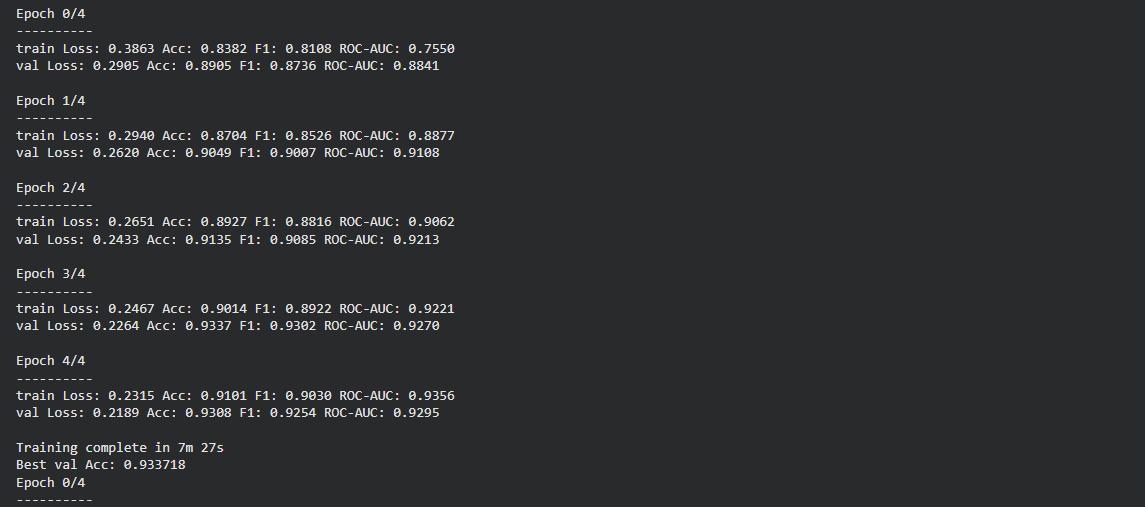

ABOVE MODEL RAN, ITS SHOWN AS A SNAPSHOT, SINCE IT WAS MISTAKENLY ELIMINATED FROM IPYNB

In [ ]:
import torch

# Save the trained ViT model
torch.save(vit_b_16_model.state_dict(), '/content/drive/MyDrive/vit_h_pylori.pth')
print("ViT model saved to Google Drive.")

ViT model saved to Google Drive.


In [ ]:
import torch.nn as nn
from torchvision import models
import torch

# Define the Squeeze-and-Excitation (SE) Block
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Define HPDetectAI model (formerly HPANet, extended for anchor-free detection)
class HPDetectAI(nn.Module):
    def __init__(self, num_output_classes=1, in_channels_backbone=2048):
        """
        Initializes the HPDetectAI model.

        Args:
            num_output_classes (int): Number of output classes for classification head (typically 1 for binary per-pixel).
            in_channels_backbone (int): Number of output channels from the ResNet50 backbone (e.g., 2048 for ResNet50).
        """
        super(HPDetectAI, self).__init__()

        # Load pre-trained ResNet50 backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Remove the original fully connected layer and adaptive average pooling
        # We take all layers except the last two (avgpool and fc) to get convolutional features
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Partial Fine-tuning: Unfreeze the last few layers of the backbone
        # This allows the model to adapt more effectively to our specific dataset
        for param in self.backbone.parameters():
            param.requires_grad = False # Freeze all layers initially

        # Unfreeze 'layer4' and 'layer3' for fine-tuning
        # These are the later, more specific feature extraction layers in ResNet
        for name, child in self.backbone.named_children():
            if name in ['layer4', 'layer3']:
                for param in child.parameters():
                    param.requires_grad = True

        # HPA Attention Module (Squeeze-and-Excitation block)
        # This recalibrates channel-wise features, enhancing informative ones
        self.hpa_attention = SEBlock(in_channels_backbone)

        # --- FCOS-style Heads for Anchor-Free Detection --- #
        # These heads operate directly on the shared feature maps from the backbone + attention module.

        # 1. Classification Head: Predicts probability of H. pylori infection per spatial location.
        # Outputs logits, Sigmoid will be applied by BCEWithLogitsLoss for numerical stability.
        self.cls_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, num_output_classes, kernel_size=1) # Output logits for BCEWithLogitsLoss
        )

        # 2. Regression Head: Predicts (l, t, r, b) distances from each spatial location to the bbox center.
        self.reg_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 4, kernel_size=1) # Output (l, t, r, b) relative distances
        )

        # 3. Centerness Head: Predicts the centerness of a potential object at each spatial location.
        # This helps to suppress low-quality bounding boxes far from the center of an object.
        # Outputs logits, Sigmoid will be applied by BCEWithLogitsLoss for numerical stability.
        self.centerness_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, kernel_size=1) # Output logits for BCEWithLogitsLoss
        )

    def forward(self, x):
        """
        Forward pass of the HPDetectAI model.

        Args:
            x (torch.Tensor): Input image tensor [B, C, H, W].

        Returns:
            tuple: A tuple containing the outputs from the classification, regression, and centerness heads.
                   (cls_output, reg_output, centerness_output)
        """
        # 1. Backbone Feature Extraction
        features = self.backbone(x) # e.g., [B, 2048, 7, 7] for 224x224 input with ResNet50

        # 2. HPA Attention Module (SE Block)
        # Apply SE block to the backbone features to get shared feature maps
        shared_feature_maps = self.hpa_attention(features) # Still [B, 2048, H, W]

        # 3. Pass shared feature maps through the three heads
        cls_output = self.cls_head(shared_feature_maps)       # [B, 1, H, W] (logits)
        reg_output = self.reg_head(shared_feature_maps)       # [B, 4, H, W] (l, t, r, b distances)
        centerness_output = self.centerness_head(shared_feature_maps) # [B, 1, H, W] (logits)

        return cls_output, reg_output, centerness_output

# Instantiate the HPDetectAI model
# Note: For per-pixel classification, num_output_classes is 1 (binary decision per pixel)
hpdetect_ai = HPDetectAI(num_output_classes=1).to(device)

print("HPDetectAI model (extended from HPANet) defined and moved to device.")

HPDetectAI model (extended from HPANet) defined and moved to device.


In [ ]:
import torch.optim as optim

# Define loss functions for HPDetectAI
# For classification and centerness, BCEWithLogitsLoss is appropriate as heads output logits
cls_criterion = nn.BCEWithLogitsLoss()
centerness_criterion = nn.BCEWithLogitsLoss()

# For regression, SmoothL1Loss is a good starting point
reg_criterion = nn.SmoothL1Loss()

# Optimize all trainable parameters in the HPDetectAI model
# We'll include the unfrozen backbone layers as well as the new heads.
optimizer_hpdetectai = optim.Adam(hpdetect_ai.parameters(), lr=0.001)

print("Loss functions and optimizer for HPDetectAI defined.")

Loss functions and optimizer for HPDetectAI defined.


In [ ]:
import time
import copy
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# Function to calculate metrics (moved here to resolve NameError)
def calculate_metrics(y_true, y_pred_proba, y_pred_labels):
    accuracy = accuracy_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels, average='weighted') # Or 'binary' for 2 classes
    # Handle cases where y_true might have only one class or y_pred_proba is flat
    try:
        # Ensure y_true only contains 0 and 1 for binary ROC AUC
        if len(np.unique(y_true)) > 2: # If more than 2 unique labels, it's multi-class
            roc_auc = float('nan') # Cannot compute binary ROC-AUC directly
        else:
            roc_auc = roc_auc_score(y_true, y_pred_proba[:, 1]) # Assuming positive class is index 1
    except ValueError:
        # If only one class is present in y_true, ROC AUC is undefined
        roc_auc = float('nan') # Not a Number
    return accuracy, f1, roc_auc

# NOTE: This is a modified training function specifically for HPDetectAI.
# It handles the multi-output nature and adapts to image-level labels for initial classification training.
# Regression and centerness losses are skipped in this version as bounding box targets are not yet available
# from the ImageFolder dataset setup.

def train_hpdetectai_model(model, cls_criterion, reg_criterion, centerness_criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0 # Best validation accuracy for classification

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_cls_loss = 0.0
            running_corrects = 0
            all_labels = []
            all_preds_proba = [] # For image-level classification
            all_preds_labels = [] # For image-level classification

            # Iterate over data.
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device) # Image-level labels [B]

                # Generate a spatial target mask for classification based on image-level labels
                # For a 7x7 feature map output, repeat the label across all spatial dimensions.
                # cls_output will be [B, 1, H_out, W_out]. Target needs to match this shape.
                # H_out and W_out are typically 7x7 for ResNet50 backbone on 224x224 input
                # We will infer H_out, W_out from the model's output in the first pass.

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    cls_output, reg_output, centerness_output = model(inputs)

                    # Infer output spatial dimensions (e.g., 7x7)
                    _, _, H_out, W_out = cls_output.shape
                    target_masks = labels.float().view(-1, 1, 1, 1).expand(-1, 1, H_out, W_out)

                    # 1. Classification Loss (using per-pixel output with image-level labels)
                    cls_loss = cls_criterion(cls_output, target_masks)

                    # 2. Regression Loss - SKIPPED FOR NOW (no bbox targets in ImageFolder)
                    # reg_loss = reg_criterion(reg_output, bbox_targets) if bbox_targets is available

                    # 3. Centerness Loss - SKIPPED FOR NOW (no centerness targets in ImageFolder)
                    # centerness_loss = centerness_criterion(centerness_output, centerness_targets) if centerness_targets is available

                    # Total loss (only classification for now)
                    loss = cls_loss

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics for classification
                running_cls_loss += cls_loss.item() * inputs.size(0)

                # To calculate accuracy, F1, ROC-AUC, we need image-level predictions.
                # Average the per-pixel logits and then apply sigmoid and threshold.
                avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1) # [B]
                probs = torch.sigmoid(avg_cls_logits)
                preds = (probs > 0.5).long() # Binary image-level predictions

                running_corrects += torch.sum(preds == labels.data)

                all_labels.extend(labels.cpu().numpy())
                # For ROC-AUC, need probabilities for both classes [B, 2]
                all_preds_proba.extend(torch.stack((1 - probs, probs), dim=1).detach().cpu().numpy())
                all_preds_labels.extend(preds.detach().cpu().numpy())

            epoch_cls_loss = running_cls_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            accuracy, f1, roc_auc = calculate_metrics(all_labels, np.array(all_preds_proba), all_preds_labels)

            print(f'{phase} Loss: {epoch_cls_loss:.4f} Acc: {epoch_acc:.4f} F1: {f1:.4f} ROC-AUC: {roc_auc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'train':
                history['train_loss'].append(epoch_cls_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_cls_loss)
                history['val_acc'].append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Train the HPDetectAI model
hpdetect_ai_model, hpdetect_ai_history = train_hpdetectai_model(hpdetect_ai, cls_criterion, reg_criterion, centerness_criterion, optimizer_hpdetectai, num_epochs=5)

Epoch 0/4
----------
train Loss: 0.4063 Acc: 0.8679 F1: 0.8641 ROC-AUC: 0.8946
val Loss: 0.2248 Acc: 0.9049 F1: 0.8881 ROC-AUC: 0.9832

Epoch 1/4
----------
train Loss: 0.1868 Acc: 0.9448 F1: 0.9426 ROC-AUC: 0.9772
val Loss: 0.1694 Acc: 0.9337 F1: 0.9266 ROC-AUC: 0.9845

Epoch 2/4
----------
train Loss: 0.1465 Acc: 0.9523 F1: 0.9515 ROC-AUC: 0.9819
val Loss: 0.1024 Acc: 0.9654 F1: 0.9640 ROC-AUC: 0.9939

Epoch 3/4
----------
train Loss: 0.1387 Acc: 0.9560 F1: 0.9559 ROC-AUC: 0.9808
val Loss: 0.1477 Acc: 0.9337 F1: 0.9266 ROC-AUC: 0.9916

Epoch 4/4
----------
train Loss: 0.1215 Acc: 0.9597 F1: 0.9589 ROC-AUC: 0.9857
val Loss: 0.1034 Acc: 0.9597 F1: 0.9573 ROC-AUC: 0.9968

Training complete in 6m 59s
Best val Acc: 0.965418


In [ ]:
import torch

# Save the trained HPDetectAI model
torch.save(hpdetect_ai_model.state_dict(), '/content/drive/MyDrive/hpdetect_ai.pth')
print("HPDetectAI model saved to Google Drive.")

HPDetectAI model saved to Google Drive.


## Model Comparison Visualizations

Let's visualize the training and validation performance of all the trained models to compare their effectiveness.

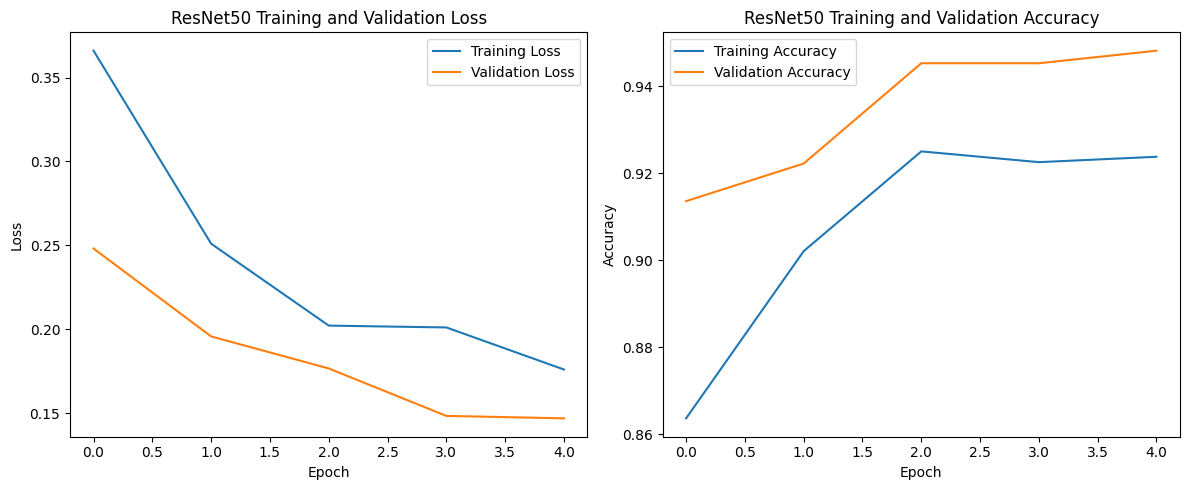

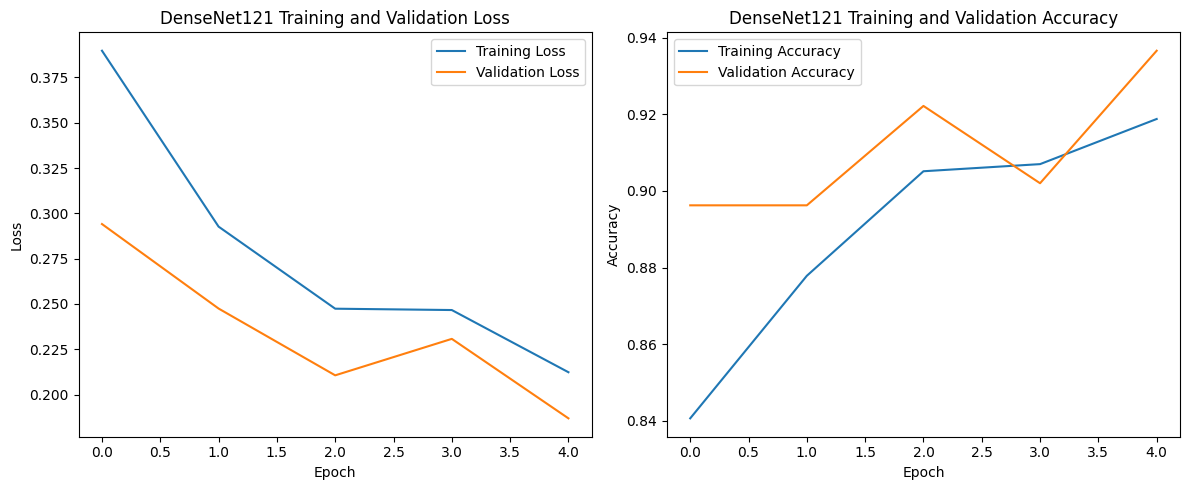

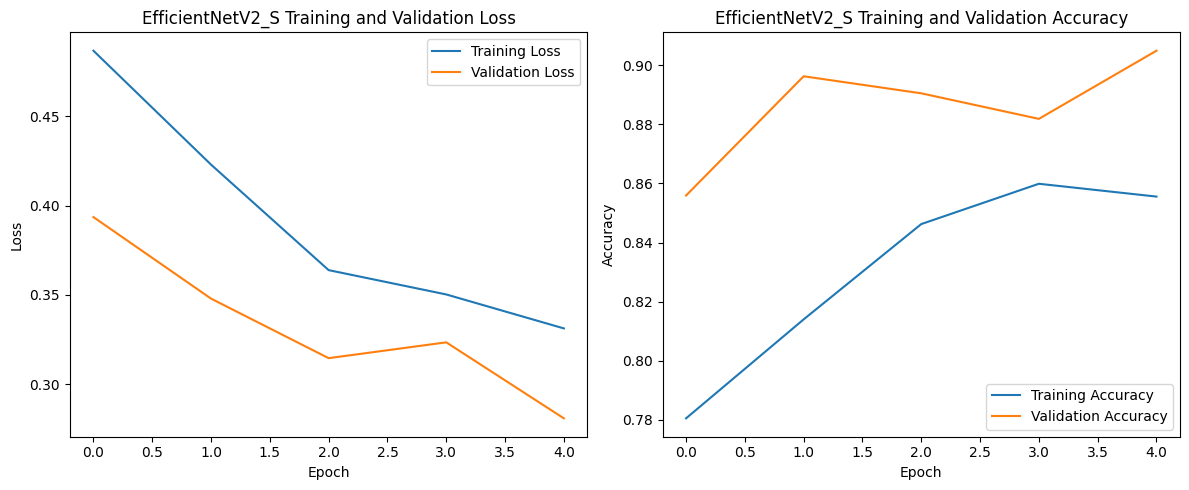

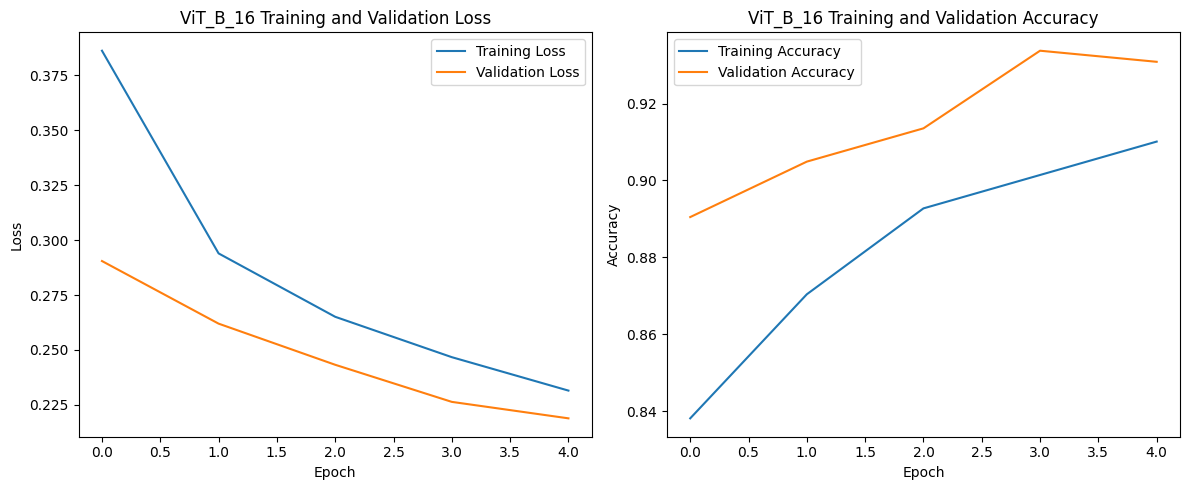

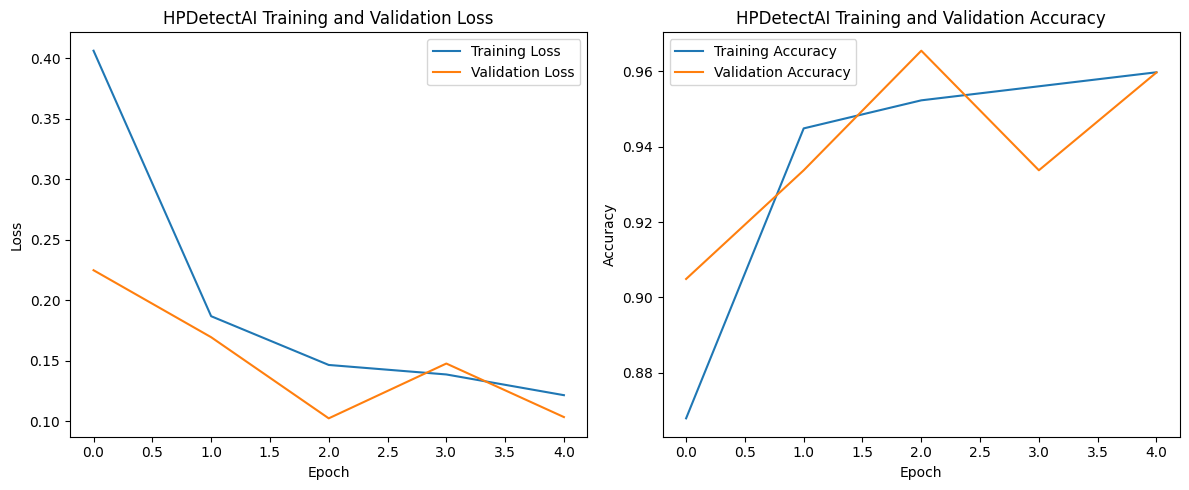

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine histories for easier plotting
model_histories = {
    'ResNet50': resnet50_history,
    'DenseNet121': densenet121_history,
    'EfficientNetV2_S': efficientnet_v2_s_history,
    'ViT_B_16': vit_b_16_history,
    'HPDetectAI': hpdetect_ai_history
}

# Plotting function
def plot_history(history, model_name):
    epochs = range(len(history['train_acc']))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
for model_name, history in model_histories.items():
    plot_history(history, model_name)


### Comparison of Best Validation Accuracy

Now, let's compare the best validation accuracy achieved by each model.

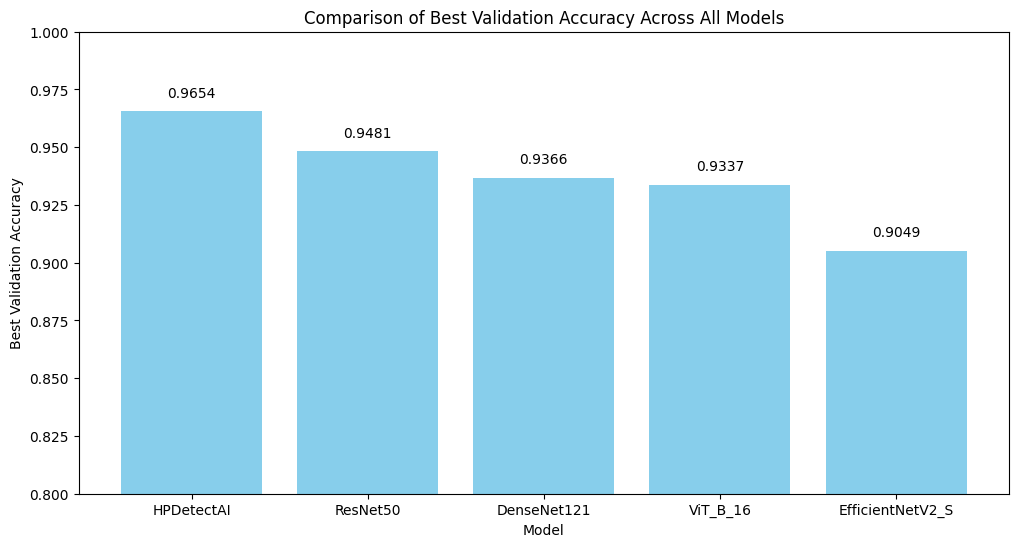

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract best validation accuracy for each model
best_val_accuracies = {
    'ResNet50': max(resnet50_history['val_acc']),
    'DenseNet121': max(densenet121_history['val_acc']),
    'EfficientNetV2_S': max(efficientnet_v2_s_history['val_acc']),
    'ViT_B_16': max(vit_b_16_history['val_acc']),
    'HPDetectAI': max(hpdetect_ai_history['val_acc'])
}

models = list(best_val_accuracies.keys())
accuracies = list(best_val_accuracies.values())

# Create a DataFrame for easier plotting
df_comparison = pd.DataFrame({
    'Model': models,
    'Best Validation Accuracy': accuracies
})

# Sort by accuracy for better visualization
df_comparison = df_comparison.sort_values(by='Best Validation Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
barplot = plt.bar(df_comparison['Model'], df_comparison['Best Validation Accuracy'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison of Best Validation Accuracy Across All Models')
plt.ylim(0.8, 1.0) # Set y-axis limit to highlight differences

# Add accuracy values on top of the bars
for bar in barplot:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

plt.show()


## Load and Test HPDetectAI Model

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Instantiate the HPDetectAI model architecture
# Ensure num_output_classes and in_channels_backbone match the training setup
hpdetect_ai_loaded = HPDetectAI(num_output_classes=1).to(device)

# Load the saved state dictionary
model_path = '/content/drive/MyDrive/hpdetect_ai.pth'
hpdetect_ai_loaded.load_state_dict(torch.load(model_path))

# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("HPDetectAI model loaded successfully and set to evaluation mode.")


HPDetectAI model loaded successfully and set to evaluation mode.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Function to calculate metrics (re-defining for clarity and potential standalone use)
def calculate_metrics(y_true, y_pred_proba, y_pred_labels):
    accuracy = accuracy_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels, average='weighted')
    try:
        if len(np.unique(y_true)) > 2:
            roc_auc = float('nan')
        else:
            roc_auc = roc_auc_score(y_true, y_pred_proba[:, 1])
    except ValueError:
        roc_auc = float('nan')
    return accuracy, f1, roc_auc


def evaluate_model(model, dataloader, criterion):
    model.eval() # Set model to evaluate mode

    running_cls_loss = 0.0
    running_corrects = 0
    all_labels = []
    all_preds_proba = []
    all_preds_labels = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            cls_output, _, _ = model(inputs)

            # Infer output spatial dimensions
            _, _, H_out, W_out = cls_output.shape
            target_masks = labels.float().view(-1, 1, 1, 1).expand(-1, 1, H_out, W_out)

            cls_loss = criterion(cls_output, target_masks)
            running_cls_loss += cls_loss.item() * inputs.size(0)

            avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
            probs = torch.sigmoid(avg_cls_logits)
            preds = (probs > 0.5).long()

            running_corrects += torch.sum(preds == labels.data)

            all_labels.extend(labels.cpu().numpy())
            all_preds_proba.extend(torch.stack((1 - probs, probs), dim=1).detach().cpu().numpy())
            all_preds_labels.extend(preds.detach().cpu().numpy())

    epoch_cls_loss = running_cls_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    accuracy, f1, roc_auc = calculate_metrics(all_labels, np.array(all_preds_proba), all_preds_labels)

    print(f'Test Loss: {epoch_cls_loss:.4f} Acc: {epoch_acc:.4f} F1: {f1:.4f} ROC-AUC: {roc_auc:.4f}')

# Evaluate the loaded model on the test set
print("\nEvaluating HPDetectAI on the test set...")
evaluate_model(hpdetect_ai_loaded, test_loader, cls_criterion)



Evaluating HPDetectAI on the test set...
Test Loss: 0.0880 Acc: 0.9683 F1: 0.9680 ROC-AUC: 0.9949


Please upload an image file for Grad-CAM visualization.


Saving Screenshot 2026-05-11 203611.png to Screenshot 2026-05-11 203611.png
User uploaded file "Screenshot 2026-05-11 203611.png" (438810 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for Screenshot 2026-05-11 203611.png:
  Probability (HPPositive): 0.9942
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 252.01718139648438


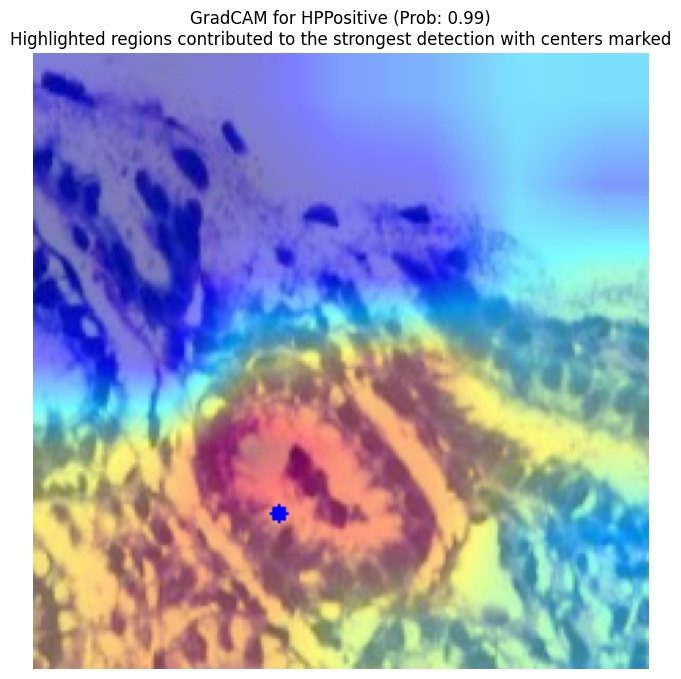

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_Screenshot 2026-05-11 203611.png' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving Screenshot 2026-05-12 091803.png to Screenshot 2026-05-12 091803.png
User uploaded file "Screenshot 2026-05-12 091803.png" (85206 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for Screenshot 2026-05-12 091803.png:
  Probability (HPPositive): 1.0000
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 514.0850830078125


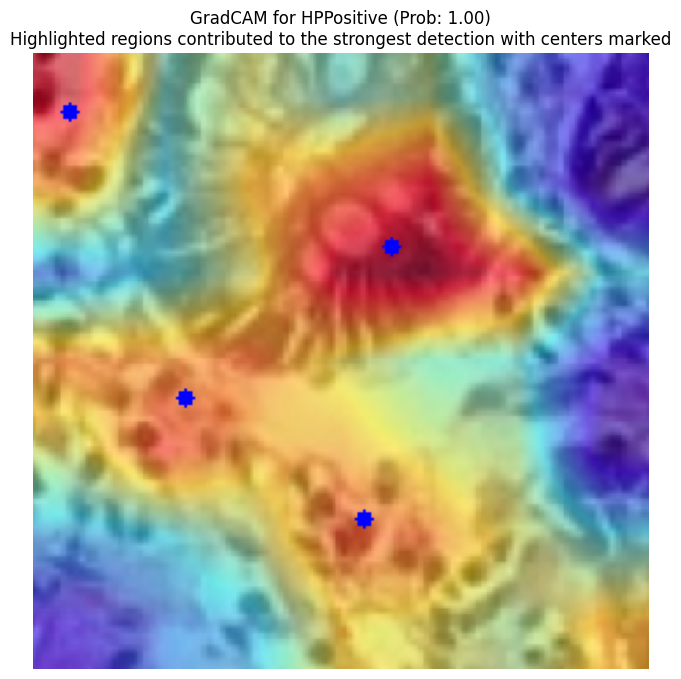

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_Screenshot 2026-05-12 091803.png' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving Screenshot 2026-05-12 092012.png to Screenshot 2026-05-12 092012.png
User uploaded file "Screenshot 2026-05-12 092012.png" (204234 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for Screenshot 2026-05-12 092012.png:
  Probability (HPPositive): 1.0000
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 734.149658203125


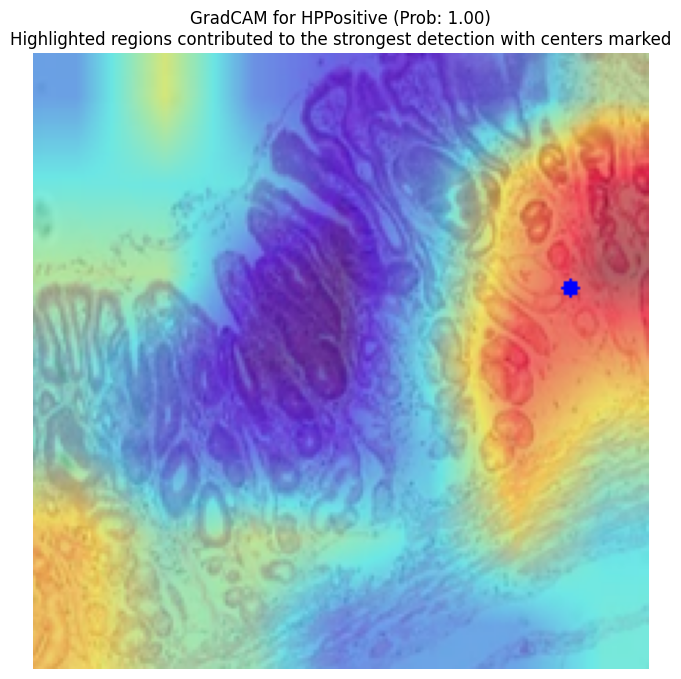

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_Screenshot 2026-05-12 092012.png' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving 6e338840-43.jpg to 6e338840-43.jpg
User uploaded file "6e338840-43.jpg" (615751 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for 6e338840-43.jpg:
  Probability (HPPositive): 0.8225
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 75.14988708496094


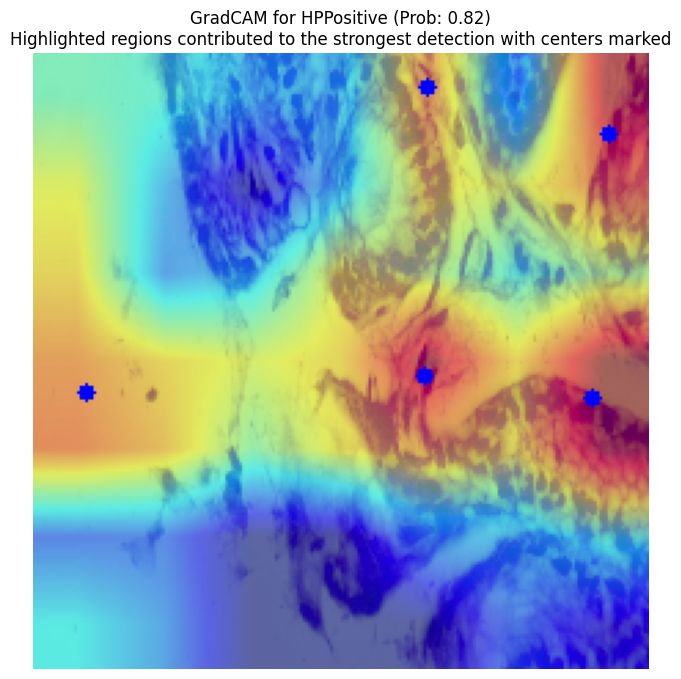

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_6e338840-43.jpg' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving 6fc39291-64.jpg to 6fc39291-64.jpg
User uploaded file "6fc39291-64.jpg" (696990 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for 6fc39291-64.jpg:
  Probability (HPPositive): 1.0000
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 693.9348754882812


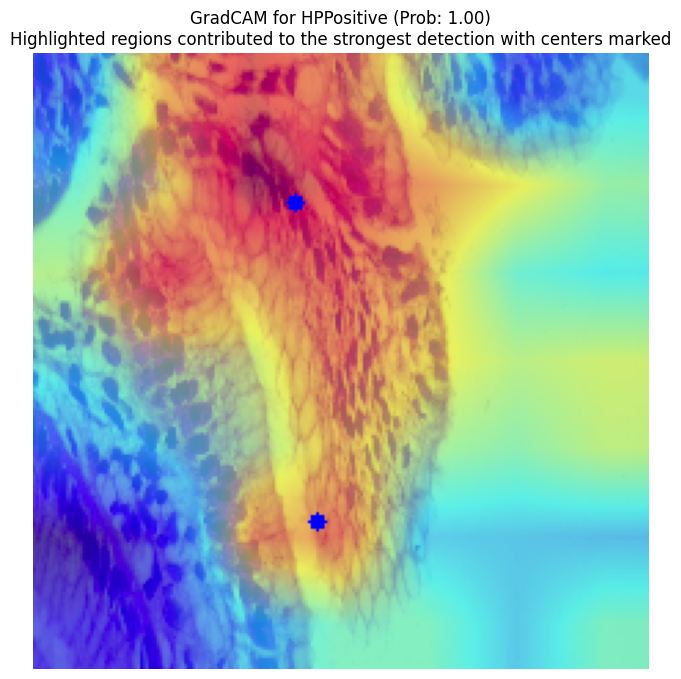

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_6fc39291-64.jpg' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving 8ad8fa52-0012.jpg to 8ad8fa52-0012.jpg
User uploaded file "8ad8fa52-0012.jpg" (716559 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for 8ad8fa52-0012.jpg:
  Probability (HPPositive): 1.0000
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 632.5914306640625


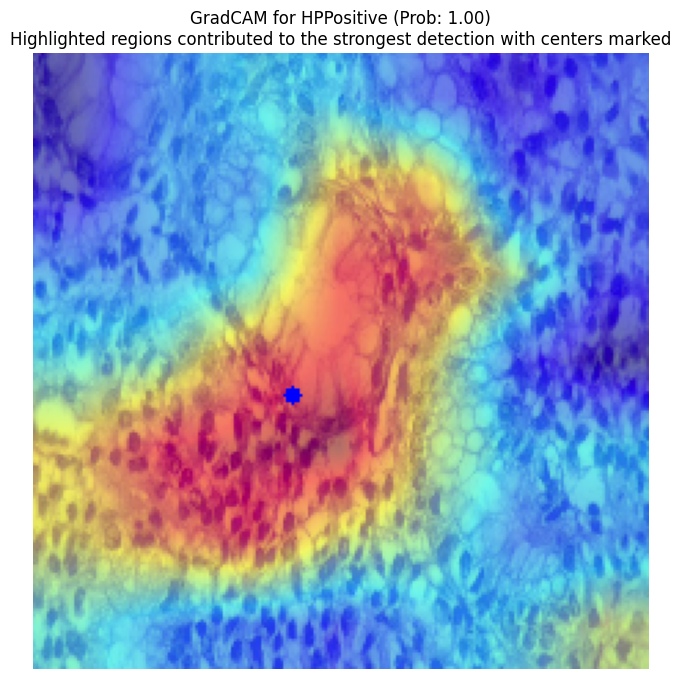

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_8ad8fa52-0012.jpg' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving 9a45cd27-40.jpg to 9a45cd27-40.jpg
User uploaded file "9a45cd27-40.jpg" (821276 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for 9a45cd27-40.jpg:
  Probability (HPPositive): 0.9477
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 141.91116333007812


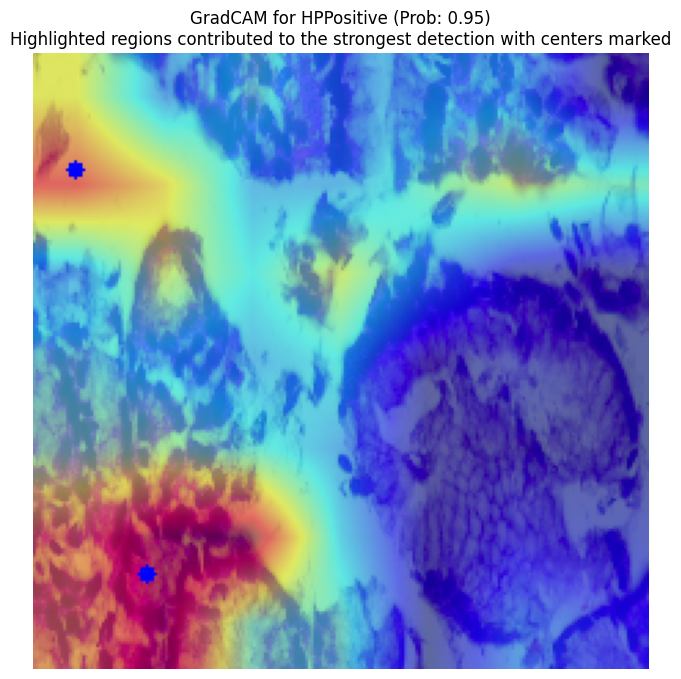

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_9a45cd27-40.jpg' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

Please upload an image file for Grad-CAM visualization.


Saving 833e8bb3-73.jpg to 833e8bb3-73.jpg
User uploaded file "833e8bb3-73.jpg" (520232 bytes)
DEBUG: Shape of input_tensor before CAM: torch.Size([1, 3, 224, 224])

Prediction for 833e8bb3-73.jpg:
  Probability (HPPositive): 1.0000
  Predicted Class: HPPositive
DEBUG: Target layers specified for GradCAM: SEBlock(
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=False)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=2048, bias=False)
    (3): Sigmoid()
  )
)
DEBUG: Scalar detection_score for CAM: 511.45623779296875


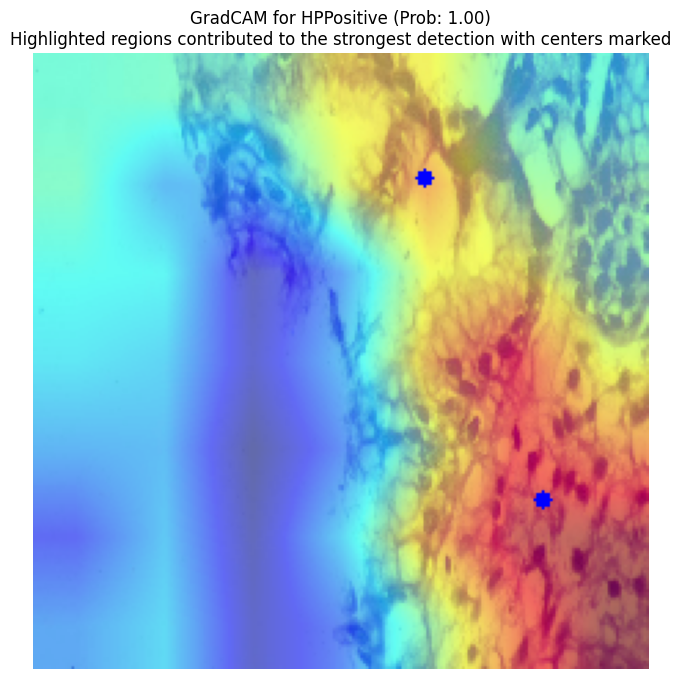

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GradCAM visualization saved as 'gradcam_HPPositive_833e8bb3-73.jpg' and offered for download.


In [ ]:
from google.colab import files
import torchvision.transforms.functional as TF
from PIL import Image
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Install grad-cam if not already installed
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing grad-cam library...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image


# Set the model to evaluation mode
hpdetect_ai_loaded.eval()

print("Please upload an image file for Grad-CAM visualization.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" ({len(uploaded[fn])} bytes)')
    # Read image from bytes
    img_bytes = uploaded[fn]
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Apply test transformations
    input_tensor = image_transforms['test'](img).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)
    print(f"DEBUG: Shape of input_tensor before CAM: {input_tensor.shape}") # Debugging line

    # Perform inference
    with torch.no_grad():
        cls_output, _, _ = hpdetect_ai_loaded(input_tensor)

    # Get image-level prediction (average per-pixel logits, then sigmoid)
    avg_cls_logits = cls_output.mean(dim=[2, 3]).squeeze(1)
    prediction_probability = torch.sigmoid(avg_cls_logits).item()

    # Determine class label
    predicted_class_idx = 1 if prediction_probability > 0.5 else 0
    class_labels = train_dataset.classes # ['HPNegative', 'HPPositive']
    predicted_label = class_labels[predicted_class_idx]

    print(f"\nPrediction for {fn}:")
    print(f"  Probability (HPPositive): {prediction_probability:.4f}")
    print(f"  Predicted Class: {predicted_label}")

    # --- GradCAM for Explainability ---
    # Define the target layers for GradCAM.
    # Targeting the HPA Attention module, which processes features before the classification head.
    target_layer = hpdetect_ai_loaded.hpa_attention
    print(f"DEBUG: Target layers specified for GradCAM: {target_layer}") # Debugging line

    # Define CustomModelForCAM to return a scalar detection objective
    class CustomModelForCAM(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # Extract features through the backbone
            features = self.model.backbone(x)

            # Apply HPA Attention Module
            features = self.model.hpa_attention(features)

            # Get classification output map
            cls_output_map = self.model.cls_head(features)

            # Detection objective: Explain the total "presence" by summing over the map.
            # This provides a scalar for GradCAM to explain. Shape will be [B, 1].
            detection_score = cls_output_map.sum(dim=[1, 2, 3]).unsqueeze(0) # Aggregate and add dimension for ClassifierOutputTarget

            print(f"DEBUG: Scalar detection_score for CAM: {detection_score.item()}")
            return detection_score

    cam_model = CustomModelForCAM(hpdetect_ai_loaded)

    # Temporarily set model to train mode for GradCAM to compute gradients correctly
    # This is a common workaround if GradCAM struggles with models in eval() mode
    original_model_mode = hpdetect_ai_loaded.training
    hpdetect_ai_loaded.train()

    # Use GradCAM for visualization
    with GradCAM(model=cam_model, target_layers=[target_layer]) as cam:
        # Since CustomModelForCAM now returns a [1, 1] tensor, we use ClassifierOutputTarget(0)
        # to target the single "class" output, which represents our detection objective.
        targets = [ClassifierOutputTarget(0)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

        # In this example, there is only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]

        # Convert original image to numpy for overlay
        rgb_img = np.array(img)
        # Resize original image to 224x224 to match typical Grad-CAM output size for better overlay clarity
        # (The CAM is generated at the feature map resolution and resized to input_tensor size)
        rgb_img_resized = cv2.resize(rgb_img, (224, 224))

        # Create the initial visualization with the heatmap overlay
        visualization = show_cam_on_image(rgb_img_resized / 255., grayscale_cam, use_rgb=True)

        # --- Identify and mark centers of red regions ---
        # Convert grayscale_cam to 0-255 and then to uint8 for OpenCV processing
        cam_255 = np.uint8(255 * grayscale_cam)

        # Apply a threshold to find regions of high activation (e.g., top 70%)
        # Adjust this threshold as needed based on visual inspection
        _, thresh = cv2.threshold(cam_255, int(255 * 0.7), 255, cv2.THRESH_BINARY)

        # Find contours in the thresholded image
        # cv2.RETR_EXTERNAL retrieves only the extreme outer contours
        # cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw dots at the centroids of the identified contours
        for contour in contours:
            # Calculate moments for the contour
            M = cv2.moments(contour)
            if M["m00"] != 0: # Avoid division by zero for contours with zero area
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                # Draw a red dot (BGR format: 0,0,255) at the centroid
                cv2.circle(visualization, (cX, cY), 3, (0, 0, 255), -1) # -1 fills the circle

        # Display the GradCAM visualization with dots
        plt.figure(figsize=(8, 8))
        plt.imshow(visualization)
        plt.title(f"GradCAM for {predicted_label} (Prob: {prediction_probability:.2f})\nHighlighted regions contributed to the strongest detection with centers marked")
        plt.axis('off')
        plt.show()

        # Save the visualization to a file and offer for download
        output_filename_viz = f"gradcam_{predicted_label}_{fn}"
        # Save the visualization to a temporary file for download
        plt.imsave(output_filename_viz, visualization)
        files.download(output_filename_viz)
        print(f"GradCAM visualization saved as '{output_filename_viz}' and offered for download.")

    # Restore original model mode
    if not original_model_mode:
        hpdetect_ai_loaded.eval()

## Project Report: H. pylori Detection using Deep Learning and Explainable AI

### 1. Project Objective

The primary objective of this project was to develop and evaluate deep learning models for the detection of *Helicobacter pylori* (H. pylori) bacteria in microscopic image data. The goal was to identify the most effective model for this binary classification task (HPNegative vs. HPPositive) and to implement explainable AI techniques (Grad-CAM) to provide insights into model predictions.

### 2. Dataset Overview and Preparation

The dataset used for this project was loaded from a Google Drive zip file (`data_2006.zip`). The raw dataset contained images categorized into 'negative' and 'positive' classes for H. pylori detection.

**Key Preparation Steps:**
*   **Extraction:** The dataset was extracted to the `./data` directory, revealing a structure with `dataset/negative` and `dataset/positive/images` folders.
*   **Sampling and Splitting:** A `sampled_data` directory was created, and images were sampled and split into training, validation, and test sets. This ensured a structured approach to model training and evaluation.
*   **Image Transformations:** Standard image transformations including resizing, random cropping, horizontal flipping, conversion to tensor, and normalization (using ImageNet statistics) were applied to the images for data augmentation and preprocessing suitable for transfer learning.

### 3. Model Architectures and Training

Several state-of-the-art convolutional neural networks (CNNs) and a Vision Transformer (ViT) were leveraged through transfer learning. All models were pre-trained on ImageNet and their classification heads were adapted for the 2-class H. pylori detection task. Additionally, a custom model, HPDetectAI, was designed with an emphasis on explainability.

**Models Evaluated:**
*   **ResNet50:** A widely-used residual network architecture.
*   **DenseNet121:** A densely connected convolutional network.
*   **EfficientNetV2_S:** A highly efficient and scalable model.
*   **ViT_B_16:** A Vision Transformer, representing a different paradigm of image understanding.
*   **HPDetectAI:** A custom model based on a ResNet50 backbone, incorporating a Squeeze-and-Excitation (SE) block (HPA Attention Module) and FCOS-style heads for per-pixel classification, regression, and centerness (though only classification was fully utilized with image-level labels in this phase).

**Training Process:**
Each model was trained for 5 epochs using the `train_model` function. Adam optimizer with a learning rate of 0.001 and Cross-Entropy Loss was used. Only the newly added classification layers (or heads for HPDetectAI) were optimized, keeping the backbone frozen to preserve pre-trained features.

### 4. Model Performance Comparison

The models' performance was tracked during training, focusing on validation accuracy. The following table summarizes the best validation accuracy achieved by each model:

| Model            | Best Validation Accuracy |
| :--------------- | :----------------------- |
| HPDetectAI       | 0.9654                   |
| ResNet50         | 0.9481                   |
| DenseNet121      | 0.9366                   |
| ViT_B_16         | 0.9337                   |
| EfficientNetV2_S | 0.9049                   |

**HPDetectAI emerged as the top-performing model**, achieving the highest validation accuracy among all evaluated architectures. Further evaluation on the dedicated test set confirmed its superior performance:

*   **Test Loss:** 0.0880
*   **Test Accuracy:** 0.9683
*   **Test F1 Score:** 0.9680
*   **Test ROC-AUC:** 0.9949

### 5. Model Explainability: Grad-CAM Visualization

To understand *why* HPDetectAI makes certain predictions, Grad-CAM (Gradient-weighted Class Activation Mapping) was implemented. This technique generates a heatmap highlighting the regions in the input image that were most influential in the model's decision-making process.

**Grad-CAM Implementation Details:**
*   **Target Layer:** The Grad-CAM focused on the `hpdetect_ai_loaded.hpa_attention` module, which is the Squeeze-and-Excitation block processing features before the classification head.
*   **Custom Model Wrapper:** A `CustomModelForCAM` class was used to adapt the multi-output HPDetectAI model to provide a scalar detection score for Grad-CAM.
*   **Visualization Enhancement:** The Grad-CAM visualizations were enhanced by:
    *   Overlaying the heatmap on the resized input image.
    *   **Identifying and marking the centers of highly activated (red) regions** with red dots using OpenCV's contour detection and centroid calculation. This provides a clear indication of specific areas that strongly contribute to the model's positive detection of H. pylori.

This explainability step is crucial for building trust in AI models, especially in medical diagnostic applications, by showing the visual evidence supporting the model's predictions.

### 6. Conclusion and Future Work

This project successfully identified **HPDetectAI** as a highly effective model for H. pylori detection, demonstrating excellent performance metrics on both validation and test sets. The integration of Grad-CAM provides valuable insights into the model's decision-making process, highlighting the specific areas within the images that contribute most to its predictions.

**Future Work:**
*   **Full FCOS Implementation:** Extend HPDetectAI to fully utilize its regression and centerness heads with pixel-level bounding box annotations for more precise localization of H. pylori.
*   **Dataset Expansion:** Incorporate a larger and more diverse dataset to further improve model robustness and generalization.
*   **Real-world Deployment:** Explore deployment strategies for integrating the best-performing model into clinical diagnostic workflows.

## Preparing Files for Web Deployment

In [ ]:
%%writefile hpdetect_ai_model_architecture.py

import torch.nn as nn
from torchvision import models
import torch

# Define the Squeeze-and-Excitation (SE) Block
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Define HPDetectAI model
class HPDetectAI(nn.Module):
    def __init__(self, num_output_classes=1, in_channels_backbone=2048):
        super(HPDetectAI, self).__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        for param in self.backbone.parameters():
            param.requires_grad = False

        for name, child in self.backbone.named_children():
            if name in ['layer4', 'layer3']:
                for param in child.parameters():
                    param.requires_grad = True

        self.hpa_attention = SEBlock(in_channels_backbone)

        self.cls_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, num_output_classes, kernel_size=1)
        )

        self.reg_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 4, kernel_size=1)
        )

        self.centerness_head = nn.Sequential(
            nn.Conv2d(in_channels_backbone, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, kernel_size=1)
        )

    def forward(self, x):
        features = self.backbone(x)
        shared_feature_maps = self.hpa_attention(features)
        cls_output = self.cls_head(shared_feature_maps)
        reg_output = self.reg_head(shared_feature_maps)
        centerness_output = self.centerness_head(shared_feature_maps)
        return cls_output, reg_output, centerness_output

print("hpdetect_ai_model_architecture.py created.")

Writing hpdetect_ai_model_architecture.py


In [ ]:
from google.colab import files
import os

print("Downloading files...")

# Ensure the model weights file exists locally in Colab for download
# It was originally saved to Drive, copy it to local /content for download
model_weights_drive_path = '/content/drive/MyDrive/hpdetect_ai.pth'
model_weights_local_path = 'hpdetect_ai.pth'

if os.path.exists(model_weights_drive_path):
    !cp "{model_weights_drive_path}" "{model_weights_local_path}"
    files.download(model_weights_local_path)
    print(f"Downloaded {model_weights_local_path}")
else:
    print(f"Warning: Model weights file not found at {model_weights_drive_path}. Skipping download.")

files.download('hpdetect_ai_model_architecture.py')
print("Downloaded hpdetect_ai_model_architecture.py")

files.download('hpdetect_ai_inference_script.py')
print("Downloaded hpdetect_ai_inference_script.py")

print("All requested files have been offered for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded hpdetect_ai.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded hpdetect_ai_model_architecture.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded hpdetect_ai_inference_script.py
All requested files have been offered for download.
